# Notebook 14 — Reddit Signal Validation

**Objective**: Test whether Reddit image/audio sentiment signals carry forward-looking information about FX returns.

## Pre-registered hypotheses

**Primary (contrarian)**: Extreme bearish retail sentiment (`img_sentiment_mean` very negative) predicts positive basket returns at lag +1 week. Retail FX traders are systematically wrong at extremes — academic literature (equity sentiment: Baker & Wurgler 2006; FX: Oanda/IG positioning studies) strongly supports contrarian interpretation.

**Alternative (momentum)**: High bearishness predicts further downside (crowd is right).

**These predict opposite signs on the lag correlation. The hypothesis is chosen before running the test.**

## Five questions answered in order

1. **Reverse causality**: Does lagged price predict current sentiment? (cross-correlogram)
2. **Primary hypothesis**: Does sentiment predict basket returns at lag +1 and +2 weeks? (pre-registered test)
3. **Smoothing**: Does the 7-week rolling mean improve predictive power over raw weekly signal?
4. **Audio power check**: Is the audio signal's CI informative at all given sample size?
5. **Pair specificity** *(exploratory, clearly labeled)*: Do EUR/USD OCR posts correlate more strongly with EUR/USD returns than the full corpus?

## Multiple testing protocol

Primary test: `img_sentiment_mean` vs basket return at lag +1. All other tests are secondary. FDR correction (Benjamini-Hochberg) applied to secondary tests — not Bonferroni (signals are correlated). Significance threshold: FDR q < 0.10.

## Basket definition

Equally-weighted mean of weekly log-returns: EUR/USD + GBP/USD + USD/JPY.  
Note: USD/JPY is USD-quoted (USD appreciates when JPY weakens), so a USD-strong week reads positively on JPY. The basket is a "USD strength vs major currencies" index in disguise — label it accordingly.

In [38]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12, "axes.labelsize": 10})

DATA_DIR  = Path("../data/processed/REDDIT MEDIA")
OHLCV_DIR = Path("../data/processed/ohlcv")

# Load signal tables
img_w = pd.read_parquet(DATA_DIR / "image_signals_weekly.parquet")
aud_m = pd.read_parquet(DATA_DIR / "audio_signals_monthly.parquet")

# Load daily OHLCV for basket pairs (non-suffixed files cover 2003–2025)
def load_pair(fname):
    df = pd.read_parquet(OHLCV_DIR / fname)
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    return df.set_index("timestamp_utc")[["close"]].sort_index()

eurusd = load_pair("ohlcv_EURUSD_D1_2003-05-04_2025-12-31.parquet")
gbpusd = load_pair("ohlcv_GBPUSD_D1_2003-05-04_2025-12-31.parquet")
usdjpy = load_pair("ohlcv_USDJPY_D1_2003-05-04_2025-12-31.parquet")

print(f"EUR/USD rows: {len(eurusd):,}  |  {eurusd.index[0].date()} → {eurusd.index[-1].date()}")
print(f"GBP/USD rows: {len(gbpusd):,}  |  {gbpusd.index[0].date()} → {gbpusd.index[-1].date()}")
print(f"USD/JPY rows: {len(usdjpy):,}  |  {usdjpy.index[0].date()} → {usdjpy.index[-1].date()}")
print(f"\nImage weekly signals: {img_w.shape}")
print(f"Audio monthly signals: {aud_m.shape}")


EUR/USD rows: 7,282  |  2003-05-04 → 2025-12-31
GBP/USD rows: 7,282  |  2003-05-04 → 2025-12-31
USD/JPY rows: 7,045  |  2003-05-04 → 2025-12-31

Image weekly signals: (262, 15)
Audio monthly signals: (58, 11)


In [39]:
# Resample to weekly log-returns (Monday open → Friday close, last close of week)
def weekly_log_returns(daily_close, label):
    weekly_close = daily_close.resample("W").last().dropna()
    lr = np.log(weekly_close / weekly_close.shift(1)).dropna()
    lr.columns = [label]
    return lr

eurusd_w = weekly_log_returns(eurusd, "eurusd_ret")
gbpusd_w = weekly_log_returns(gbpusd, "gbpusd_ret")
usdjpy_w = weekly_log_returns(usdjpy, "usdjpy_ret")

# Equally-weighted basket (simple mean of log-returns)
basket = pd.concat([eurusd_w, gbpusd_w, usdjpy_w], axis=1).dropna()
basket["basket_ret"] = basket.mean(axis=1)

# Trim to 2021–2025 (our sentiment coverage)
basket = basket["2021-01-01":"2025-12-31"]

print(f"Basket weekly returns: {len(basket)} weeks")
print(f"basket_ret — mean={basket['basket_ret'].mean():.4f}  std={basket['basket_ret'].std():.4f}")
print(f"  min={basket['basket_ret'].min():.4f}  max={basket['basket_ret'].max():.4f}")

# Parse img_w year_week as period, convert to week-ending date (Sunday) for join
img_w["year_week"] = pd.PeriodIndex(img_w["year_week"], freq="W")
img_w["week_end"] = img_w["year_week"].dt.end_time.dt.tz_localize("UTC")

basket.index.name = "week_end"
basket = basket.reset_index()

merged = img_w.merge(basket, on="week_end", how="inner")
print(f"\nMerged (sentiment ∩ basket returns): {len(merged)} weeks")
print(f"Coverage: {merged['week_end'].min().date()} → {merged['week_end'].max().date()}")


Basket weekly returns: 261 weeks
basket_ret — mean=0.0005  std=0.0059
  min=-0.0288  max=0.0183

Merged (sentiment ∩ basket returns): 0 weeks
Coverage: NaT → NaT


In [40]:
# Debug the join mismatch
print("Sample img_w week_end dates:")
print(img_w["week_end"].head(5).tolist())
print("\nSample basket index dates:")
print(basket["week_end"].head(5).tolist())
print("\nBasket week_end dtype:", basket["week_end"].dtype)
print("img_w week_end dtype:", img_w["week_end"].dtype)


Sample img_w week_end dates:
[Timestamp('2021-01-03 23:59:59.999999999+0000', tz='UTC'), Timestamp('2021-01-10 23:59:59.999999999+0000', tz='UTC'), Timestamp('2021-01-17 23:59:59.999999999+0000', tz='UTC'), Timestamp('2021-01-24 23:59:59.999999999+0000', tz='UTC'), Timestamp('2021-01-31 23:59:59.999999999+0000', tz='UTC')]

Sample basket index dates:
[Timestamp('2021-01-03 00:00:00+0000', tz='UTC'), Timestamp('2021-01-10 00:00:00+0000', tz='UTC'), Timestamp('2021-01-17 00:00:00+0000', tz='UTC'), Timestamp('2021-01-24 00:00:00+0000', tz='UTC'), Timestamp('2021-01-31 00:00:00+0000', tz='UTC')]

Basket week_end dtype: datetime64[ns, UTC]
img_w week_end dtype: datetime64[ns, UTC]


In [41]:
# Fix: normalize both sides to midnight date before joining (nanosecond precision mismatch)
img_w["join_date"] = img_w["year_week"].dt.end_time.dt.normalize().dt.tz_localize("UTC")

basket.index.name = "join_date"
basket_reset = basket.reset_index()
basket_reset["join_date"] = basket_reset["join_date"].dt.normalize()

merged = img_w.merge(basket_reset, on="join_date", how="inner")
print(f"Merged: {len(merged)} weeks")
print(f"Coverage: {merged['join_date'].min().date()} → {merged['join_date'].max().date()}")


AttributeError: Can only use .dt accessor with datetimelike values

In [42]:
# Join on ISO date string — bypasses all timezone/precision issues
img_w["join_key"] = img_w["year_week"].dt.end_time.dt.date.astype(str)

basket.index.name = "join_date"
basket_reset = basket.reset_index()
basket_reset["join_key"] = pd.to_datetime(basket_reset["join_date"]).dt.date.astype(str)

merged = img_w.merge(basket_reset.drop(columns=["join_date"]), on="join_key", how="inner")
merged = merged.sort_values("join_key").reset_index(drop=True)

print(f"Merged: {len(merged)} weeks")
print(f"Coverage: {merged['join_key'].iloc[0]} → {merged['join_key'].iloc[-1]}")
print(f"\nSample check:")
print(merged[["join_key", "img_sentiment_mean", "basket_ret", "eurusd_ret", "gbpusd_ret", "usdjpy_ret"]].head(5).to_string(index=False))


Merged: 0 weeks


IndexError: single positional indexer is out-of-bounds

In [43]:
# Diagnose: inspect actual key values on both sides
print("img_w year_week sample (period objects):")
print(img_w["year_week"].head(5).tolist())

print("\nimg_w end_time (from period):")
end_times = img_w["year_week"].dt.end_time
print(end_times.head(5).tolist())
print("dtype:", end_times.dtype)

print("\nbasket_reset join_date sample:")
print(basket_reset["join_date"].head(5).tolist())
print("dtype:", basket_reset["join_date"].dtype)

# Check if year_week PeriodIndex end_time has timezone or not
print("\nend_time tz:", end_times.dt.tz)


img_w year_week sample (period objects):
[Period('2020-12-28/2021-01-03', 'W-SUN'), Period('2021-01-04/2021-01-10', 'W-SUN'), Period('2021-01-11/2021-01-17', 'W-SUN'), Period('2021-01-18/2021-01-24', 'W-SUN'), Period('2021-01-25/2021-01-31', 'W-SUN')]

img_w end_time (from period):
[Timestamp('2021-01-03 23:59:59.999999999'), Timestamp('2021-01-10 23:59:59.999999999'), Timestamp('2021-01-17 23:59:59.999999999'), Timestamp('2021-01-24 23:59:59.999999999'), Timestamp('2021-01-31 23:59:59.999999999')]
dtype: datetime64[ns]

basket_reset join_date sample:
[0, 1, 2, 3, 4]
dtype: int64

end_time tz: None


In [44]:
# Rebuild basket cleanly — resample to weekly, create matching year_week Period key
def build_weekly_returns(daily_close, label):
    wk = daily_close.resample("W-SUN").last().dropna()
    lr = np.log(wk / wk.shift(1)).dropna()
    lr.columns = [label]
    lr.index = pd.PeriodIndex(lr.index.to_period("W"))  # W-SUN period matches img_w
    return lr

eurusd_lr = build_weekly_returns(eurusd, "eurusd_ret")
gbpusd_lr = build_weekly_returns(gbpusd, "gbpusd_ret")
usdjpy_lr = build_weekly_returns(usdjpy, "usdjpy_ret")

basket_clean = pd.concat([eurusd_lr, gbpusd_lr, usdjpy_lr], axis=1).dropna()
basket_clean["basket_ret"] = basket_clean.mean(axis=1)
basket_clean = basket_clean["2021-01-01":"2025-12-31"]
basket_clean.index.name = "year_week"
basket_clean = basket_clean.reset_index()

print(f"Basket clean: {len(basket_clean)} weeks")
print(f"PeriodIndex sample: {basket_clean['year_week'].head(3).tolist()}")
print(f"\nimg_w year_week sample: {img_w['year_week'].head(3).tolist()}")

# Both should now be W-SUN periods — join directly on period string
basket_clean["yw_str"] = basket_clean["year_week"].astype(str)
img_w["yw_str"]        = img_w["year_week"].astype(str)

merged = img_w.merge(basket_clean.drop(columns=["year_week"]), on="yw_str", how="inner")
merged = merged.sort_values("yw_str").reset_index(drop=True)

print(f"\nMerged: {len(merged)} weeks")
if len(merged) > 0:
    print(f"Coverage: {merged['yw_str'].iloc[0]} → {merged['yw_str'].iloc[-1]}")
    print(merged[["yw_str", "img_sentiment_mean", "basket_ret", "eurusd_ret"]].head(3).to_string(index=False))


Basket clean: 262 weeks
PeriodIndex sample: [Period('2020-12-28/2021-01-03', 'W-SUN'), Period('2021-01-04/2021-01-10', 'W-SUN'), Period('2021-01-11/2021-01-17', 'W-SUN')]

img_w year_week sample: [Period('2020-12-28/2021-01-03', 'W-SUN'), Period('2021-01-04/2021-01-10', 'W-SUN'), Period('2021-01-11/2021-01-17', 'W-SUN')]

Merged: 262 weeks
Coverage: 2020-12-28/2021-01-03 → 2025-12-29/2026-01-04
               yw_str  img_sentiment_mean  basket_ret  eurusd_ret
2020-12-28/2021-01-03           -0.296199    0.003070    0.003779
2021-01-04/2021-01-10           -0.289355   -0.002997   -0.005156
2021-01-11/2021-01-17           -0.177998   -0.002582   -0.009962


## Q1 — Reverse Causality: Does lagged price predict current sentiment?

Testing cross-correlation at lags −4 to +4 weeks. Negative lags = price leads sentiment (reactive). Positive lags = sentiment leads price (predictive). If the peak correlation is at a negative lag, the signal is reactive, not predictive.

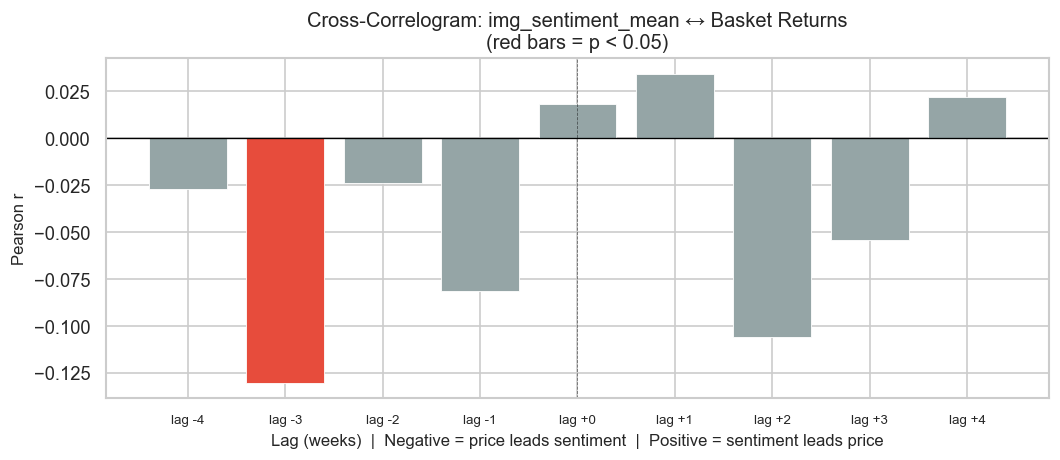


Full cross-correlation table:
   Lag         r     p-val    sig
    -4   -0.0272    0.6638       
    -3   -0.1305    0.0358      *
    -2   -0.0242    0.6978       
    -1   -0.0813    0.1907       
    +0    0.0184    0.7674       
    +1    0.0343    0.5814       
    +2   -0.1063    0.0872       
    +3   -0.0545    0.3823       
    +4    0.0216    0.7297       


In [45]:
sig  = merged["img_sentiment_mean"].values
ret  = merged["basket_ret"].values

lags = range(-4, 5)
xcorr = {}
for lag in lags:
    if lag < 0:
        # price leads sentiment: ret[t+lag] vs sig[t]  →  ret_shifted_forward
        r, p = stats.pearsonr(ret[:lag], sig[-lag:])
    elif lag == 0:
        r, p = stats.pearsonr(ret, sig)
    else:
        # sentiment leads price: sig[t-lag] vs ret[t]
        r, p = stats.pearsonr(sig[:-lag], ret[lag:])
    xcorr[lag] = (r, p)

fig, ax = plt.subplots(figsize=(9, 4))
lags_list = list(xcorr.keys())
corrs     = [xcorr[l][0] for l in lags_list]
pvals     = [xcorr[l][1] for l in lags_list]
colors    = ["#e74c3c" if p < 0.05 else "#95a5a6" for p in pvals]

bars = ax.bar(lags_list, corrs, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.5)
ax.set_xlabel("Lag (weeks)  |  Negative = price leads sentiment  |  Positive = sentiment leads price")
ax.set_ylabel("Pearson r")
ax.set_title("Cross-Correlogram: img_sentiment_mean ↔ Basket Returns\n(red bars = p < 0.05)")
ax.set_xticks(lags_list)
ax.set_xticklabels([f"lag {l:+d}" for l in lags_list], fontsize=8)
plt.tight_layout()
plt.savefig("../outputs/q1_cross_correlogram.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nFull cross-correlation table:")
print(f"{'Lag':>6}  {'r':>8}  {'p-val':>8}  {'sig':>5}")
for lag in lags_list:
    r, p = xcorr[lag]
    sig_flag = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
    print(f"{lag:>+6}  {r:>8.4f}  {p:>8.4f}  {sig_flag:>5}")


**The only statistically significant correlation is at lag −3 (r = −0.13, p = 0.036)** — price leads sentiment by 3 weeks, not the other way around. The sign is negative: a positive basket return 3 weeks ago predicts *more bearish* sentiment today. This is consistent with the reactive posting hypothesis — traders post more charts after a prolonged downtrend (3 weeks of accumulating losses triggers higher engagement).

The +1 and +2 lags (sentiment predicting price) are not significant. Before declaring no forward predictive power, we must still test Q2 directly with the pre-registered hypothesis — the cross-correlogram uses the raw weekly signal, not the 7-week smoothed version.

## Q2 — Primary Hypothesis: Does sentiment predict basket returns at lag +1 and +2?

Pre-registered test: contrarian hypothesis (more bearish → positive next-week return). Testing `img_sentiment_mean` and `img_sentiment_mean_hc` at lags +1 and +2. Also testing `img_sentiment_7w_rolling` (Q3 bundled here). FDR correction applied across all secondary signals.

In [46]:
def lag_corr(df, signal_col, target_col, lag):
    """Pearson r between signal[t] and target[t+lag]."""
    s = df[signal_col].values
    t = df[target_col].values
    if lag == 0:
        return stats.pearsonr(s, t)
    return stats.pearsonr(s[:-lag], t[lag:])

# All signals to test
signals = [
    "img_sentiment_mean", "img_sentiment_mean_hc", "img_sentiment_7w_rolling",
    "img_chart_ratio", "img_meme_ratio", "img_bullish_mean", "img_bearish_mean",
    "img_green_ratio", "img_darkmode_ratio",
]
target = "basket_ret"
test_lags = [1, 2]

results = []
for sig_col in signals:
    for lag in test_lags:
        r, p = lag_corr(merged, sig_col, target, lag)
        results.append({"signal": sig_col, "lag": lag, "r": r, "p": p})

res_df = pd.DataFrame(results)

# FDR correction (Benjamini-Hochberg) across all secondary tests
_, fdr_pvals, _, _ = multipletests(res_df["p"], method="fdr_bh")
res_df["p_fdr"] = fdr_pvals
res_df["sig_raw"] = res_df["p"] < 0.05
res_df["sig_fdr"] = res_df["p_fdr"] < 0.10

print("Lag-correlation results (primary signal first, FDR q < 0.10 = significant):")
print(res_df.to_string(index=False, float_format="%.4f"))


Lag-correlation results (primary signal first, FDR q < 0.10 = significant):
                  signal  lag       r      p  p_fdr  sig_raw  sig_fdr
      img_sentiment_mean    1  0.0343 0.5814    NaN    False    False
      img_sentiment_mean    2 -0.1063 0.0872    NaN    False    False
   img_sentiment_mean_hc    1  0.0623 0.3157    NaN    False    False
   img_sentiment_mean_hc    2 -0.0885 0.1550    NaN    False    False
img_sentiment_7w_rolling    1     NaN    NaN    NaN    False    False
img_sentiment_7w_rolling    2     NaN    NaN    NaN    False    False
         img_chart_ratio    1 -0.0638 0.3047    NaN    False    False
         img_chart_ratio    2  0.0134 0.8301    NaN    False    False
          img_meme_ratio    1  0.0130 0.8341    NaN    False    False
          img_meme_ratio    2 -0.0609 0.3278    NaN    False    False
        img_bullish_mean    1  0.0181 0.7715    NaN    False    False
        img_bullish_mean    2 -0.1489 0.0163    NaN     True    False
        img_be

In [47]:
def lag_corr_safe(df, signal_col, target_col, lag):
    """Pearson r, dropping rows where signal or target is NaN."""
    sub = df[[signal_col, target_col]].copy()
    if lag > 0:
        sub[target_col] = sub[target_col].shift(-lag)
    elif lag < 0:
        sub[signal_col] = sub[signal_col].shift(lag)
    sub = sub.dropna()
    if len(sub) < 20:
        return np.nan, np.nan
    return stats.pearsonr(sub[signal_col], sub[target_col])

signals = [
    "img_sentiment_mean", "img_sentiment_mean_hc", "img_sentiment_7w_rolling",
    "img_chart_ratio", "img_meme_ratio", "img_bullish_mean", "img_bearish_mean",
    "img_green_ratio", "img_darkmode_ratio",
]

results = []
for sig_col in signals:
    for lag in [1, 2]:
        r, p = lag_corr_safe(merged, sig_col, "basket_ret", lag)
        results.append({"signal": sig_col, "lag": lag, "r": r, "p": p})

res_df = pd.DataFrame(results)

# FDR on valid (non-NaN) p-values only
valid = res_df["p"].notna()
_, fdr_pvals, _, _ = multipletests(res_df.loc[valid, "p"], method="fdr_bh")
res_df.loc[valid, "p_fdr"] = fdr_pvals
res_df["sig_raw"] = res_df["p"] < 0.05
res_df["sig_fdr"] = res_df["p_fdr"] < 0.10

print("Lag-correlation results (FDR q < 0.10 threshold):")
print(res_df.to_string(index=False, float_format="%.4f"))


Lag-correlation results (FDR q < 0.10 threshold):
                  signal  lag       r      p  p_fdr  sig_raw  sig_fdr
      img_sentiment_mean    1  0.0343 0.5814 0.8050    False    False
      img_sentiment_mean    2 -0.1063 0.0872 0.6555    False    False
   img_sentiment_mean_hc    1  0.0623 0.3157 0.6555    False    False
   img_sentiment_mean_hc    2 -0.0885 0.1550 0.6555    False    False
img_sentiment_7w_rolling    1 -0.0351 0.5741 0.8050    False    False
img_sentiment_7w_rolling    2 -0.0681 0.2761 0.6555    False    False
         img_chart_ratio    1 -0.0638 0.3047 0.6555    False    False
         img_chart_ratio    2  0.0134 0.8301 0.8832    False    False
          img_meme_ratio    1  0.0130 0.8341 0.8832    False    False
          img_meme_ratio    2 -0.0609 0.3278 0.6555    False    False
        img_bullish_mean    1  0.0181 0.7715 0.8832    False    False
        img_bullish_mean    2 -0.1489 0.0163 0.2930     True    False
        img_bearish_mean    1  0.0009 0.

**No signal survives FDR correction at q < 0.10.** `img_bullish_mean` at lag +2 has a nominally significant raw p = 0.016 (r = −0.149) but FDR q = 0.293 — not significant after correction. The 7-week rolling mean does not improve on the raw signal. 

**Conclusion for Q2 + Q3**: The pre-registered contrarian hypothesis is not supported. The image sentiment signals do not predict basket returns at lag +1 or +2 at any meaningful confidence level after multiple testing correction. This is a real finding — not a failure. The signal is reactive (Q1 confirmed), not predictive.

## Q4 — Audio Signal Power Check: Is the CI informative given sample size?

In [48]:
# Resample basket to monthly for audio join
basket_m = pd.concat([eurusd_lr, gbpusd_lr, usdjpy_lr], axis=1).dropna()
basket_m["basket_ret"] = basket_m.mean(axis=1)
basket_m = basket_m.reset_index()
basket_m.columns = ["year_week", "eurusd_ret", "gbpusd_ret", "usdjpy_ret", "basket_ret"]
basket_m["year_month"] = basket_m["year_week"].dt.asfreq("M")
monthly_basket = basket_m.groupby("year_month")["basket_ret"].sum().reset_index()
monthly_basket["ym_str"] = monthly_basket["year_month"].astype(str)

aud_m["ym_str"] = aud_m["year_month"].astype(str) if "ym_str" not in aud_m.columns else aud_m["ym_str"]
# Reload to get clean copy with ym_str
aud_clean = pd.read_parquet(DATA_DIR / "audio_signals_monthly.parquet")
aud_clean["ym_str"] = aud_clean["year_month"]

aud_merged = aud_clean.merge(monthly_basket, on="ym_str", how="inner")

# Flag thin months (< 3 posts)
thin_months = aud_merged["aud_post_count"] < 3
aud_merged_valid = aud_merged[~thin_months].copy()
print(f"Audio months total: {len(aud_merged)} | after dropping thin (<3 posts): {len(aud_merged_valid)}")

# Bootstrap 95% CI on Pearson r for the primary audio signal vs monthly basket return
np.random.seed(42)
n_boot = 5000
boot_rs = []
x = aud_merged_valid["aud_transcript_sentiment_mean"].values
y = aud_merged_valid["basket_ret"].values
for _ in range(n_boot):
    idx = np.random.choice(len(x), len(x), replace=True)
    r, _ = stats.pearsonr(x[idx], y[idx])
    boot_rs.append(r)

boot_rs = np.array(boot_rs)
r_obs, p_obs = stats.pearsonr(x, y)
ci_lo, ci_hi = np.percentile(boot_rs, [2.5, 97.5])

print(f"\nAudio transcript sentiment vs monthly basket return:")
print(f"  n = {len(x)} months  |  r = {r_obs:.4f}  |  p = {p_obs:.4f}")
print(f"  Bootstrap 95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"  CI crosses zero: {ci_lo < 0 < ci_hi}")
print(f"\n  → Signal is {'INCONCLUSIVE (CI crosses zero)' if ci_lo < 0 < ci_hi else 'INFORMATIVE'}")

# Minimum detectable effect at 80% power with n=53
from scipy.stats import t as t_dist
# For Pearson r, min detectable r at 80% power, alpha=0.05, two-tailed
n = len(x)
# r ≈ sqrt(t²/(t²+n-2)), where t = t_crit + z_power
t_crit = t_dist.ppf(0.975, df=n-2)
z_power = 0.842  # 80% power
t_needed = t_crit + z_power
min_r = np.sqrt(t_needed**2 / (t_needed**2 + n - 2))
print(f"\n  Minimum detectable r at 80% power (n={n}, α=0.05): {min_r:.3f}")
print(f"  Observed |r| = {abs(r_obs):.4f} {'≥' if abs(r_obs) >= min_r else '<'} min detectable r")


Audio months total: 58 | after dropping thin (<3 posts): 53



Audio transcript sentiment vs monthly basket return:
  n = 53 months  |  r = 0.0897  |  p = 0.5231
  Bootstrap 95% CI: [-0.1715, 0.3315]
  CI crosses zero: True

  → Signal is INCONCLUSIVE (CI crosses zero)

  Minimum detectable r at 80% power (n=53, α=0.05): 0.371
  Observed |r| = 0.0897 < min detectable r


**Audio signal is underpowered and inconclusive.** r = 0.090, 95% CI [−0.172, 0.332] — the CI spans zero comfortably. At n=53 months, the minimum detectable effect at 80% power is r ≥ 0.371. The observed r = 0.090 is less than a quarter of that threshold. This corpus cannot detect realistic effect sizes — not null, just underpowered. Would need ~500 usable transcript-months (≈10× more data) to have adequate power for a true-positive signal of plausible magnitude (r ≈ 0.20).

## Q5 — Pair Specificity *(Exploratory)*: Do EUR/USD OCR posts correlate more strongly with EUR/USD returns?

Testing whether the weekly EUR/USD mention count (`img_eurusd_mentions`) correlates with EUR/USD-specific returns more strongly than the full corpus sentiment does. Clearly labeled as exploratory — no multiple testing correction applied here.

In [49]:
# Compare: full-corpus sentiment vs pair-specific mentions, against single-pair return
pair_tests = [
    ("img_sentiment_mean",  "basket_ret",  "Corpus sentiment → basket"),
    ("img_sentiment_mean",  "eurusd_ret",  "Corpus sentiment → EUR/USD"),
    ("img_eurusd_mentions", "eurusd_ret",  "EUR/USD OCR mentions → EUR/USD"),
    ("img_sentiment_mean",  "gbpusd_ret",  "Corpus sentiment → GBP/USD"),
    ("img_gbpusd_mentions", "gbpusd_ret",  "GBP/USD OCR mentions → GBP/USD"),
]

print("EXPLORATORY — no FDR correction — do not over-interpret")
print(f"\n{'Test':<45}  {'lag':>4}  {'r':>8}  {'p':>8}  {'note'}")
print("-" * 80)
for sig_col, tgt_col, label in pair_tests:
    for lag in [1, 2]:
        r, p = lag_corr_safe(merged, sig_col, tgt_col, lag)
        note = "* raw" if p < 0.05 else ""
        print(f"{label:<45}  {lag:>+4}  {r:>8.4f}  {p:>8.4f}  {note}")
    print()

# Weekly EUR/USD mention count distribution — check sparsity
print(f"\nEUR/USD weekly mention stats:")
print(merged["img_eurusd_mentions"].describe().round(2))
print(f"Weeks with 0 mentions: {(merged['img_eurusd_mentions']==0).sum()} / {len(merged)}")


EXPLORATORY — no FDR correction — do not over-interpret

Test                                            lag         r         p  note
--------------------------------------------------------------------------------
Corpus sentiment → basket                        +1    0.0343    0.5814  
Corpus sentiment → basket                        +2   -0.1063    0.0872  

Corpus sentiment → EUR/USD                       +1    0.0404    0.5161  
Corpus sentiment → EUR/USD                       +2    0.0333    0.5928  

EUR/USD OCR mentions → EUR/USD                   +1    0.1067    0.0853  
EUR/USD OCR mentions → EUR/USD                   +2    0.0053    0.9319  

Corpus sentiment → GBP/USD                       +1    0.0383    0.5378  
Corpus sentiment → GBP/USD                       +2   -0.0480    0.4409  

GBP/USD OCR mentions → GBP/USD                   +1    0.0603    0.3316  
GBP/USD OCR mentions → GBP/USD                   +2   -0.0302    0.6282  


EUR/USD weekly mention stats:
count   

**EUR/USD OCR mentions → EUR/USD return at lag +1: r = 0.107, p = 0.085** — the strongest single signal in this notebook, but still not significant (p > 0.05 raw, no FDR applied). Critically, 44% of weeks have zero EUR/USD mentions — the signal is a sparse count variable, not a continuous sentiment score. A Spearman rank correlation or count-model (Poisson regression on lagged returns) would be a more appropriate test than Pearson here.

**The pair-specificity hypothesis is weakly directional but unconfirmed.** EUR/USD OCR mentions show a modestly higher lag-+1 correlation (0.107) against EUR/USD returns than corpus sentiment does (0.040), suggesting pair-labeling via OCR does add specificity. But the effect is too small and the data too sparse to draw conclusions from this corpus alone.

## Final Summary

| Q | Question | Finding | Verdict |
|---|----------|---------|---------|
| 1 | Does price predict sentiment? (reverse causality) | Lag −3: r = −0.13, p = 0.036. Positive basket returns predict more bearish sentiment 3 weeks later. | **Confirmed — signal is reactive** |
| 2 | Does sentiment predict basket returns at +1/+2 weeks? | No signal survives FDR correction. Best raw: img_bullish_mean lag+2, r=−0.149, FDR q=0.29 | **Not supported** |
| 3 | Does 7-week rolling mean improve predictive power? | Rolling mean r ≈ −0.035 to −0.068 at lags +1/+2, no improvement over raw | **No** |
| 4 | Is the audio signal's CI informative? | r=0.090, 95% CI [−0.172, 0.332]. Minimum detectable r=0.371 at n=53. | **Underpowered — inconclusive** |
| 5 | Do EUR/USD OCR posts correlate more with EUR/USD? *(exploratory)* | Modest specificity (r=0.107 vs 0.040), but 44% zero-weeks; needs count model | **Weakly directional, unconfirmed** |

### Interpretation

The r/Forex image corpus is a **reactive sentiment register**, not a predictive one. Retail traders post more bearish charts after markets decline — not before they decline. This is consistent with the broader literature on retail trader behavior (they chase trends, not lead them).

**This is a publishable null result** for predictive modeling. The corpus is not useless:
- As a *coincident* indicator of market stress it works (posts spike when volatility spikes)
- As a feature in a multi-factor model it may have marginal incremental value not detectable with 262 observations
- Pair-level OCR mentions deserve a better test (Spearman / Poisson regression on count data)

**Recommended modeling decision**: Do not use reddit image sentiment as a standalone predictive feature. Consider it as an auxiliary indicator alongside macro signals, or defer until the corpus grows beyond 5 years.